In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
from utils.persistence_utils import (
    build_snapshot_index, iter_snapshot_models, extract_linear_importance
)

import pandas as pd
import seaborn as sns
import utils.base_utils as bu
import utils.window_utils as wu
import numpy as np
from utils.macro_grouping import add_group_level, build_full_group_mapping, groups_as_array

# Bianchi period:
start_date = '1971-08-31'
end_date = '2018-12-31'

# end_date = '2025-06-30' # kr and gsw end date
maturities = [str(i) for i in range(12, 121) if i % 12 == 0] # select only yearly maturities

yields = bu.get_yields(type='lw', start=start_date, end=end_date, maturities=maturities) # type can be kr, lw, gsw
forward = bu.get_forward_rates(yields)
xr = bu.get_excess_returns(yields, horizon=12).dropna() # horizon=12 means holding for 12 months
fred_md_raw = bu.get_fred_data('data/2026-01-MD.csv', start=start_date, end=end_date) # this is aligned to the last day of the previous month, so we get the same number of observations as the yields data

monthly_yields = bu.get_yields(type='lw', start=start_date, end=end_date, maturities=[str(i) for i in range(1, 121)]) # needed for monthly holding period excess returns. Not available for gsw
monthly_xr = bu.get_excess_returns(monthly_yields, horizon=1).dropna() # calculate monthly excess returns for robustness

# At time t (end of month), we only know data for month t-1
fred_md = fred_md_raw.shift(1)  

# Drop dates outside the xr range
yields = yields.loc[yields.index <= xr.index[-1]]
forward = forward.loc[forward.index <= xr.index[-1]]
xr = xr.loc[xr.index <= xr.index[-1]]
fred_md = fred_md.loc[fred_md.index <= xr.index[-1]]
monthly_xr = monthly_xr.loc[monthly_xr.index <= xr.index[-1]]

# Backfill fred_md to avoid nans
fred_md = fred_md.bfill()

# Construct X with 3-level MultiIndex: (source, group, series)
s2g = build_full_group_mapping(fred_md, forward, yields)

X = pd.concat([fred_md, forward, yields],
               axis=1,
               keys=['fred', 'forward', 'yields'])

X = add_group_level(X, s2g, level_name='group')
X = X.sort_index(axis=1, level='group')
groups = groups_as_array(X, level='group')

y_all = xr[['24','36','48','60','72','84','96','108','120']].values
dates = xr.index

y = monthly_xr['120'].values # 1-month excess returns
# y = xr['120'].values # 10-year overlapping excess returns
OOS_start = pd.Timestamp('1990-01-31')
# OOS_start = pd.Timestamp('1972-01-31')

# Coefficients for linear models

In [ ]:
run_name = "pcamg_100seeds_monthly"
idx = build_snapshot_index(run_name)
print(idx.head(), "\nTotal snapshots:", len(idx))

# Example: collect |coef| paths for stability plots
rows = []
for rec, model in iter_snapshot_models(run_name, seeds=range(0, 100)):
    imp = extract_linear_importance(model)
    if imp is None:
        continue
    rows.append({
        "seed": rec["seed"],
        "refit_i": rec["refit_i"],
        "date": rec["date"],
        "importance": imp
    })

coef_df = pd.DataFrame(rows)
print("Linear snapshots with importances:", len(coef_df))

# Shap analysis for ANNs

In [2]:
from utils.shap_utils import run_ann_shap_over_time

run_name = "fwnn_5seeds_monthly"

# For multi-output monthly_xr[['24',...,'120']], target 0..8
shap_df = run_ann_shap_over_time(
    run_name=run_name,
    X=X,
    seeds=range(0, 5),
    every_n_refits=12,      # speed-up (monthly refits -> yearly samples)
    gap=0,
    background_size=128,
    explain_size=1,
    target_indices=list(range(9)),
    use_unscaled_output=True
)

print(shap_df.head())
print("Rows:", len(shap_df))

# Example aggregate: feature stability over time
agg = (shap_df
       .groupby(["date", "feature_name"], as_index=False)["mean_abs_shap"]
       .mean()
       .sort_values(["date", "mean_abs_shap"], ascending=[True, False]))

SHAP snapshots [fwnn_5seeds_monthly]: 0it [00:00, ?it/s]

targets seed=0 step=0:   0%|          | 0/9 [00:00<?, ?it/s]

targets seed=0 step=12:   0%|          | 0/9 [00:00<?, ?it/s]

targets seed=0 step=24:   0%|          | 0/9 [00:00<?, ?it/s]

targets seed=0 step=36:   0%|          | 0/9 [00:00<?, ?it/s]

...

targets seed=4 step=288:   0%|          | 0/9 [00:00<?, ?it/s]

targets seed=4 step=300:   0%|          | 0/9 [00:00<?, ?it/s]

targets seed=4 step=312:   0%|          | 0/9 [00:00<?, ?it/s]

targets seed=4 step=324:   0%|          | 0/9 [00:00<?, ?it/s]

   seed  refit_i  t_index       date  target_idx input_branch  feature_idx  \
0     0        0      221 1990-01-31           0      forward            0   
1     0        0      221 1990-01-31           0      forward            1   
2     0        0      221 1990-01-31           0      forward            2   
3     0        0      221 1990-01-31           0      forward            3   
4     0        0      221 1990-01-31           0      forward            4   

  feature_name  mean_abs_shap  
0  Yields::108       0.011917  
1   Yields::12       0.010051  
2  Yields::120       0.000063  
3   Yields::24       0.009984  
4   Yields::36       0.015933  
Rows: 12600


# Preliminary plots

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

def make_shap_panel(shap_df, target_idx=0, model_name=None, branch=None, freq="Q"):
    d = shap_df.copy()
    if target_idx is not None:
        d = d[d["target_idx"] == target_idx]
    if model_name is not None and "model_name" in d.columns:
        d = d[d["model_name"] == model_name]
    if branch is not None:
        d = d[d["input_branch"] == branch]

    d["date_bin"] = pd.to_datetime(d["date"]).dt.to_period(freq).dt.to_timestamp()
    panel = (d.groupby(["date_bin", "feature_name"], as_index=False)["mean_abs_shap"]
               .mean())
    return panel

def plot_shap_heatmap(panel, top_k=25, normalize="row", title="SHAP heatmap"):
    wide = panel.pivot(index="feature_name", columns="date_bin", values="mean_abs_shap").fillna(0.0)
    top = wide.mean(axis=1).sort_values(ascending=False).head(top_k).index
    M = wide.loc[top]

    if normalize == "row":
        denom = M.max(axis=1).replace(0, 1.0)
        M = M.div(denom, axis=0)
    elif normalize == "col":
        denom = M.max(axis=0).replace(0, 1.0)
        M = M.div(denom, axis=1)

    plt.figure(figsize=(14, max(6, top_k * 0.28)))
    sns.heatmap(M, cmap="mako", cbar=True)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

def plot_top_feature_trajectories(panel, top_k=10, rolling=4, title="Top feature SHAP over time"):
    wide = panel.pivot(index="date_bin", columns="feature_name", values="mean_abs_shap").fillna(0.0)
    top = wide.mean(axis=0).sort_values(ascending=False).head(top_k).index
    S = wide[top].rolling(rolling, min_periods=1).mean()

    plt.figure(figsize=(14, 6))
    for c in S.columns:
        plt.plot(S.index, S[c], label=c, linewidth=1.8)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Mean |SHAP|")
    plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
    plt.tight_layout()
    plt.show()

def topk_jaccard_over_time(panel, k=10):
    wide = panel.pivot(index="date_bin", columns="feature_name", values="mean_abs_shap").fillna(0.0)
    dates = wide.index.tolist()
    rows = []

    prev = None
    for dt in dates:
        cur = set(wide.loc[dt].sort_values(ascending=False).head(k).index)
        if prev is None:
            jac = np.nan
        else:
            jac = len(prev & cur) / max(1, len(prev | cur))
        rows.append({"date_bin": dt, "jaccard_topk_vs_prev": jac})
        prev = cur
    return pd.DataFrame(rows)

def plot_jaccard_stability(jacc_df, title="Top-k feature set stability (Jaccard)"):
    plt.figure(figsize=(12, 4))
    plt.plot(jacc_df["date_bin"], jacc_df["jaccard_topk_vs_prev"], marker="o")
    plt.ylim(0, 1)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Jaccard with previous period")
    plt.tight_layout()
    plt.show()

In [7]:
import numpy as np
import pandas as pd
import utils.window_utils as wu
from utils.persistence_utils import build_snapshot_index, load_snapshot_model

def forecast_from_snapshots(run_name, seed, X, y, dates, oos_start, gap=0, refit_freq=1, root_dir="artifacts/models"):
    idx = build_snapshot_index(run_name=run_name, root_dir=root_dir)
    idx = idx[idx["seed"] == int(seed)].sort_values("refit_i")

    if idx.empty:
        raise ValueError(f"No snapshots for run={run_name}, seed={seed}")

    path_by_refit = dict(zip(idx["refit_i"].astype(int), idx["model_path"]))
    oos_indices = np.where(dates >= oos_start)[0]

    y_forecast = np.full_like(y, np.nan, dtype=float) if y.ndim == 1 else np.full(y.shape, np.nan, dtype=float)

    model = None
    for i, t in enumerate(oos_indices):
        if i % refit_freq == 0:
            if i not in path_by_refit:
                raise ValueError(f"Missing snapshot for seed={seed}, refit_i={i}")
            model = load_snapshot_model(path_by_refit[i])

        pred = model.predict(X.iloc[[t]])
        if y.ndim == 1:
            y_forecast[t] = float(np.asarray(pred).reshape(-1)[0])
        else:
            y_forecast[t, :] = np.asarray(pred).reshape(-1)

    return y_forecast

def r2_oos_by_seed(run_name, X, y, dates, oos_start, seeds=None, gap=0, refit_freq=1, benchmark="hist_mean"):
    idx = build_snapshot_index(run_name=run_name)
    available_seeds = sorted(idx["seed"].unique().tolist())
    if seeds is None:
        seeds = available_seeds
    else:
        seeds = [s for s in seeds if s in available_seeds]

    rows = []
    for s in seeds:
        yhat = forecast_from_snapshots(run_name, s, X, y, dates, oos_start, gap=gap, refit_freq=refit_freq)
        r2 = wu.oos_r2(y, yhat, benchmark=benchmark)

        if np.ndim(r2) == 0:
            rows.append({"run_name": run_name, "seed": s, "target_idx": -1, "r2_oos": float(r2)})
        else:
            for j, v in enumerate(r2):
                rows.append({"run_name": run_name, "seed": s, "target_idx": j, "r2_oos": float(v)})

    return pd.DataFrame(rows)

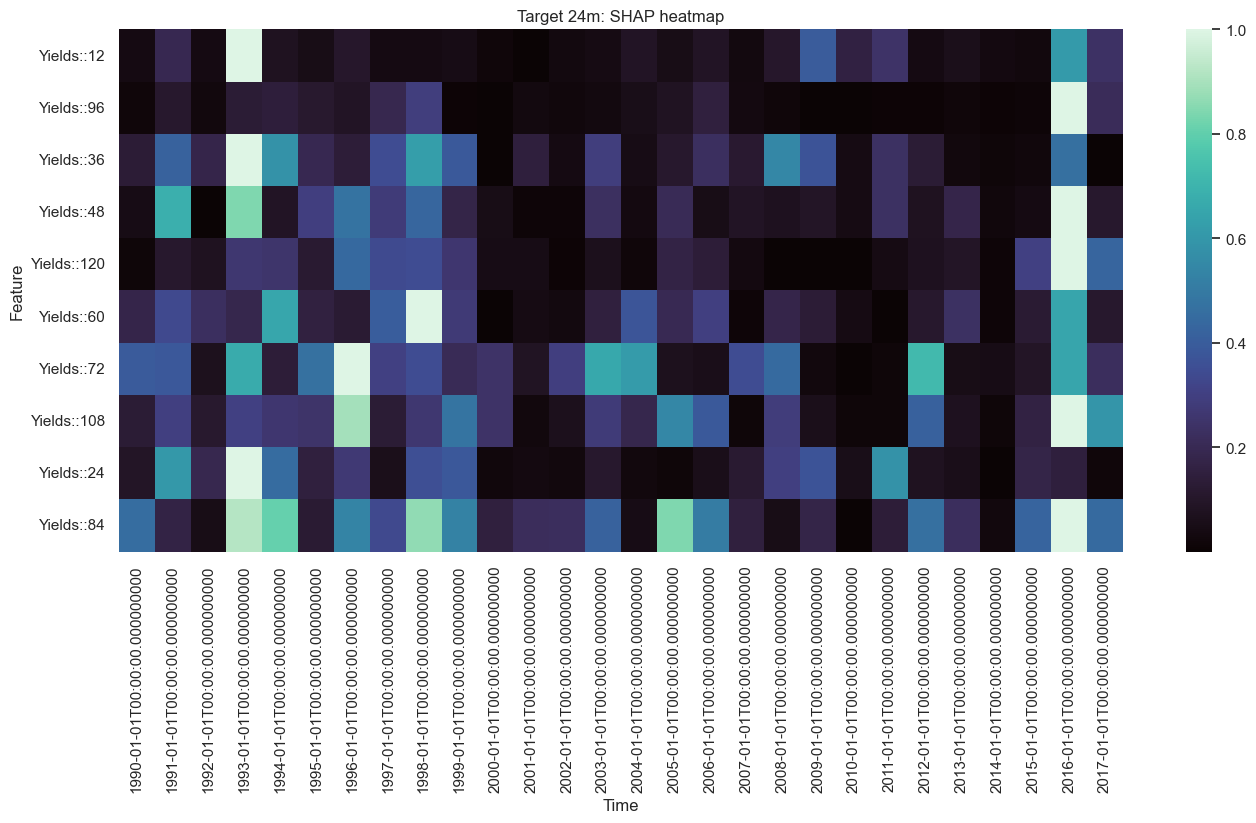

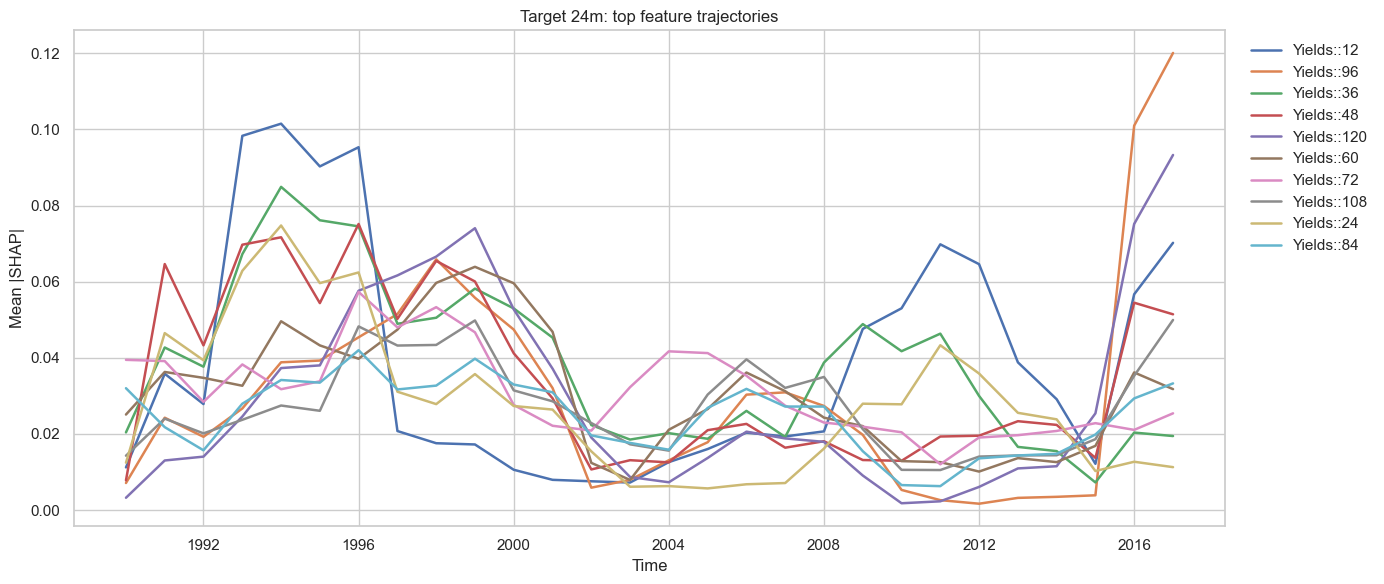

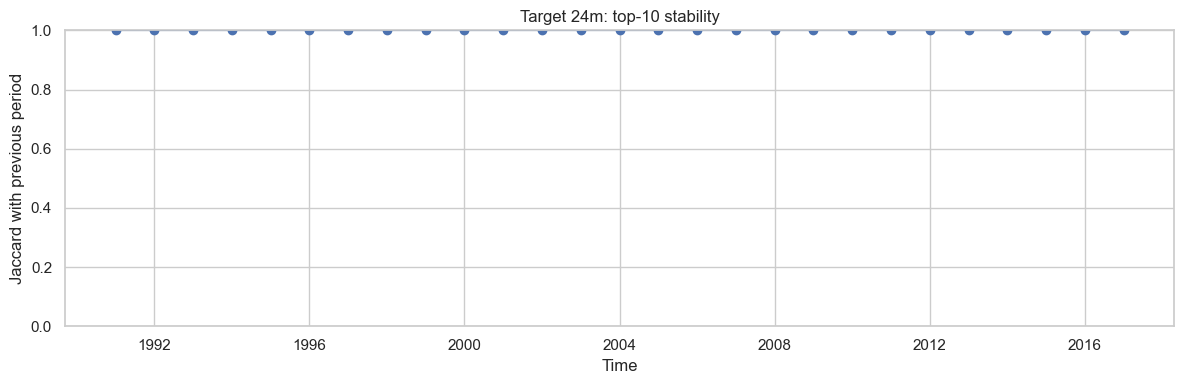

,run_name,seed,target_idx,r2_oos
0,fwnn_5seeds_monthly,0,0,-0.226488
1,fwnn_5seeds_monthly,0,1,-0.131868
2,fwnn_5seeds_monthly,0,2,-0.123303
3,fwnn_5seeds_monthly,0,3,-0.225981
4,fwnn_5seeds_monthly,0,4,-0.189907


In [8]:
panel = make_shap_panel(shap_df, target_idx=0, freq="Q")
plot_shap_heatmap(panel, top_k=30, normalize="row", title="Target 24m: SHAP heatmap")
plot_top_feature_trajectories(panel, top_k=12, rolling=4, title="Target 24m: top feature trajectories")

jacc = topk_jaccard_over_time(panel, k=10)
plot_jaccard_stability(jacc, title="Target 24m: top-10 stability")

# R²_OOS per seed
r2_seed_df = r2_oos_by_seed(
    run_name="fwnn_5seeds_monthly",
    X=X, y=y_all, dates=dates, oos_start=OOS_start,
    seeds=range(0, 5), gap=0, refit_freq=1, benchmark="hist_mean"
)
r2_seed_df.head()